In [1]:
# Requiero Mesa >= 3.5
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''SingleGrid''.
from mesa.space import SingleGrid

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

# Importamos esta librería para generar numeros aleatorios más adelante
import sys
import random
from matplotlib.colors import ListedColormap

import heapq


In [2]:
def get_grid(model):
    grid = np.zeros( (model.grid.width, model.grid.height) )
    for content, (x, y) in model.grid.coord_iter():
        grid[x][y] = model.cells[x][y]
        if content != None:
            grid[x][y] = 7
    return grid

In [7]:
class FlashPoint(Model):
    def __init__(self, width=10, height=8, agents=1, **kwargs):
        super().__init__()
        self.grid = SingleGrid(width, height, torus = False)
        self.cells = np.zeros( (width, height) )
        
        self.datacollector = DataCollector(model_reporters={
            "Grid" : get_grid} )

    def step(self):
        self.datacollector.collect(self)

In [8]:
MAX_GENERATIONS = 200

model = FlashPoint()
for i in range(MAX_GENERATIONS):
    model.step()

In [9]:
all_grids = model.datacollector.get_model_vars_dataframe()

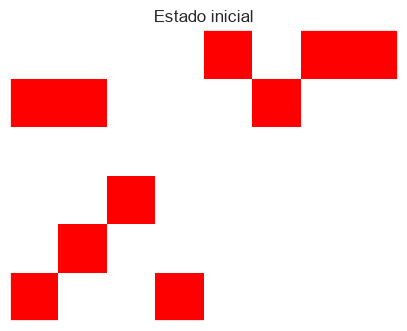

In [ ]:
# Fuego

ROWS_FUEGO = 6
COLS_FUEGO = 8

FUEGO_INICIAL = [
    (1, 7), (4, 3), (5, 2), (1, 5), (2, 2),
    (2, 6), (6, 1), (1, 8), (2, 1), (6, 4),
]

# 0 = vacio, 1 = humo, 2 = fuego
matrixFuego = np.zeros((ROWS_FUEGO, COLS_FUEGO), dtype=int)


for fila, columna in FUEGO_INICIAL:
    matrixFuego[fila - 1, columna - 1] = 2

# Falta poner el daño a las paredes
# Falta hacer si un fuego cae en PDI
# Falta hacer debilitamiento si cae un fuego en un bombero

def explosion(r, c, matrix):

    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # arriba, abajo, izquierda, derecha
    for dr, dc in direcciones:
        nr, nc = r + dr, c + dc
        while 0 <= nr < ROWS_FUEGO and 0 <= nc < COLS_FUEGO and matrix[nr, nc] == 2:
            nr += dr
            nc += dc
        if 0 <= nr < ROWS_FUEGO and 0 <= nc < COLS_FUEGO:
            matrix[nr, nc] = 2  # vacio o humo -> fuego

def flashover(matrix):

    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    cambio = True
    while cambio:
        cambio = False
        for i in range(ROWS_FUEGO):
            for j in range(COLS_FUEGO):
                if matrix[i, j] != 1:
                    continue
                for dr, dc in direcciones:
                    ni, nj = i + dr, j + dc
                    if 0 <= ni < ROWS_FUEGO and 0 <= nj < COLS_FUEGO and matrix[ni, nj] == 2:
                        matrix[i, j] = 2
                        cambio = True
                        break

def advance_fire(matrix):

    fila = random.randint(1, ROWS_FUEGO)
    columna = random.randint(1, COLS_FUEGO)
    r, c = fila - 1, columna - 1

    # Cae humo
    if matrix[r, c] == 0:
        matrix[r, c] = 1

    # Se convierte en fuego
    elif matrix[r, c] == 1:
        matrix[r, c] = 2

    # Explosion
    elif matrix[r, c] == 2:
        explosion(r, c, matrix)
    return fila, columna

N_TURNOS_FUEGO = 20
historyFuego = [matrixFuego.copy()]
historyTargetFuego = [None]
historyEventoFuego = [None]  

for _ in range(N_TURNOS_FUEGO):
    antes = matrixFuego.copy()
    fila, columna = advance_fire(matrixFuego)
    evento = "explosion" if antes[fila - 1, columna - 1] == 2 else None
    flashover(matrixFuego)
    historyFuego.append(matrixFuego.copy())
    historyTargetFuego.append((fila, columna))
    historyEventoFuego.append(evento)

fuego_cmap = ListedColormap(["white", "gray", "red"])
fig_fuego, ax_fuego = plt.subplots(figsize=(5, 4))
ax_fuego.set_xticks([])
ax_fuego.set_yticks([])
patch_fuego = ax_fuego.imshow(historyFuego[0], cmap=fuego_cmap, vmin=0, vmax=2)
title_fuego = ax_fuego.set_title("Estado inicial")

def animate_fuego(i):
    patch_fuego.set_data(historyFuego[i])
    target = historyTargetFuego[i]
    if target is None:
        title_fuego.set_text("Estado inicial")
    else:
        evento = historyEventoFuego[i]
        extra = " - EXPLOSION" if evento == "explosion" else ""
        title_fuego.set_text(f"Turno {i} - cae en (fila {target[0]}, columna {target[1]}){extra}")
    return patch_fuego, title_fuego

anim_fuego = animation.FuncAnimation(
    fig_fuego, animate_fuego, frames=len(historyFuego), interval=600
)
anim_fuego

NameError: name 'all_grids' is not defined

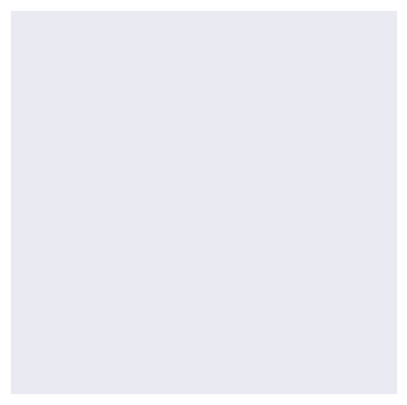

In [5]:
fig, axis = plt.subplots(figsize=(5, 5))
axis.set_xticks([])
axis.set_yticks([])
patch = plt.imshow(all_grids.iloc[0,0], cmap=plt.cm.binary)

def animate(i):
    patch.set_data(all_grids.iloc[i,0])

anim = animation.FuncAnimation(fig, animate, frames=MAX_GENERATIONS)

In [11]:
anim